In [846]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [847]:
dataset = pd.read_excel("combined.xlsx")

In [848]:
#colums of  dataset
dataset.columns

Index(['Date', 'Date of Loss', 'Company Name', 'Details', 'Sender Email',
       'Claim Status', 'Claim number', 'Insurance company', 'Adjuster Info',
       'Unnamed: 9', 'Notes'],
      dtype='str')

In [849]:
#Dataset Cleaning

In [850]:
#dataset.head(5)
dataset.tail(5)

,Date,Date of Loss,Company Name,Details,Sender Email,Claim Status,Claim number,Insurance company,Adjuster Info,Unnamed: 9,Notes
142,06/25/2026,06/23/2026,Rashed Transport LLC,APD,salehfarag@hotmail.com,Active,26-80-37359,"Fortegra, CTA",Adjuster:\nKrystin Correa\n404-841-0001 ext 25...,NaN,Insured truck was by another truck while turni...
143,2026-07-07 00:00:00,02/17/2026,W&A Trucking LLC,NTL,noor_almaslawi@yahoo.com,Active,NaN,"Dynamic, AIFE",NaN,NaN,Received a letter from the attorney office to ...
144,06/30/2026,06/23/2026,Rashed Transport LLC,AL,ftclaims@penske.com,Closed,NaN,Penske,NaN,NaN,NaN
145,2026-08-07 00:00:00,06/22/2026,Tern Freight Inc,AL,ternfreight@gmail.com (shivam),Active,8849917030000000,GEICO (3rd party),NaN,NaN,Geico cx hit our client while driving out of t...
146,2026-08-07 00:00:00,2026-02-07 00:00:00,MGI EXPRESS LLC,AL,rotextransportation@gmail.com,Active,NaN,XPT,NaN,NaN,Our client backed into other vehicle while rev...


In [851]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Date               146 non-null    object
 1   Date of Loss       146 non-null    object
 2   Company Name       147 non-null    str   
 3   Details            147 non-null    str   
 4   Sender Email       144 non-null    str   
 5   Claim Status       146 non-null    str   
 6   Claim number       126 non-null    object
 7   Insurance company  142 non-null    str   
 8   Adjuster Info      116 non-null    str   
 9   Unnamed: 9         16 non-null     str   
 10  Notes              16 non-null     str   
dtypes: object(3), str(8)
memory usage: 12.8+ KB


In [852]:
# a Rename column Date to Date of filing and details to Policy type.
# b Drop column notes, unnamed, adjuster info.
# c change data type of Date of filing, date of loss - datetime and claim number - string
# d fix missing values - Date of filing, date of loss, sender email, claim status, claim number, insurance company, adjuster info

In [853]:
# a Rename column Date to Date of filing and details to Policy type.
dataset.rename(columns={"Date" : "Date_of_filing", "Details" : "Policy_type"}, inplace=True)
dataset.head(5)

,Date_of_filing,Date of Loss,Company Name,Policy_type,Sender Email,Claim Status,Claim number,Insurance company,Adjuster Info,Unnamed: 9,Notes
0,07/22/2024,07/20/2024,USA TRUCKLINES LLC,PD claim,usatrucklinesllc1@gmail.com,Closed,GPA24-3925,"Dynamic, UNIC","Kimberly Nash-Williams, knash-williams@mccordc...",NaN,NaN
1,04/26/2024,04/16/2024,Hasco LLC,PD Claim,hasco55@yahoo.com,Closed,GPA24-3879,"Dynamic, UNIC",Claim Handler: Kimberly Nash-Williams ...,NaN,NaN
2,07/22/2024,07/15/2024,ZEENA TRUKING LLC,PD claim,zaid20047@hotmail.com,Closed,NaN,"Dynamic, UNIC",NaN,NaN,NaN
3,2024-05-06 00:00:00,05/31/2024,Alfa Freightline LLC,APD,alfafreightline@gmail.com,Active,GPK24-3794,"IRIS, UNIC",the adjuster is Michelle Taylor PH: 402-514-62...,NaN,NaN
4,06/21/2024,2024-05-06 00:00:00,A Z Trans LLC,APD,ops@lightingti.com,Closed,GPA24-3962,"Dynamic, UNIC","Colt Ford Direct, cford@mccordclaims.com, (402...",NaN,NaN


In [854]:
# b Drop column notes, unnamed, adjuster info.
dataset.drop(dataset.columns[-2:], axis=1, inplace=True)
dataset.head(5)

,Date_of_filing,Date of Loss,Company Name,Policy_type,Sender Email,Claim Status,Claim number,Insurance company,Adjuster Info
0,07/22/2024,07/20/2024,USA TRUCKLINES LLC,PD claim,usatrucklinesllc1@gmail.com,Closed,GPA24-3925,"Dynamic, UNIC","Kimberly Nash-Williams, knash-williams@mccordc..."
1,04/26/2024,04/16/2024,Hasco LLC,PD Claim,hasco55@yahoo.com,Closed,GPA24-3879,"Dynamic, UNIC",Claim Handler: Kimberly Nash-Williams ...
2,07/22/2024,07/15/2024,ZEENA TRUKING LLC,PD claim,zaid20047@hotmail.com,Closed,NaN,"Dynamic, UNIC",NaN
3,2024-05-06 00:00:00,05/31/2024,Alfa Freightline LLC,APD,alfafreightline@gmail.com,Active,GPK24-3794,"IRIS, UNIC",the adjuster is Michelle Taylor PH: 402-514-62...
4,06/21/2024,2024-05-06 00:00:00,A Z Trans LLC,APD,ops@lightingti.com,Closed,GPA24-3962,"Dynamic, UNIC","Colt Ford Direct, cford@mccordclaims.com, (402..."


In [855]:
# c Change data type of claim number to string and save.
dataset['Claim number'] = dataset['Claim number'].astype(str)

In [856]:
dataset['Date_of_filing'] = dataset['Date_of_filing'].astype(str)


In [857]:
dataset['Date of Loss'] = dataset['Date of Loss'].astype(str)

In [858]:
import re

def clean_date(x):
    if pd.isna(x):
        return pd.NaT

    x = str(x)
    x = re.sub(r"\s*\(.*\)$", "", x)  # Remove "(Eastern Daylight Time)"
    x = x.replace("GMT", "")          # Remove "GMT"

    return pd.to_datetime(x, errors="coerce")

dataset["Date_of_filing"] = dataset["Date_of_filing"].apply(clean_date)

In [859]:
dataset.loc[40, "Date_of_filing"] = pd.Timestamp("2025-02-20")

In [860]:
dataset[dataset["Date_of_filing"].isna()]

,Date_of_filing,Date of Loss,Company Name,Policy_type,Sender Email,Claim Status,Claim number,Insurance company,Adjuster Info


In [861]:
dataset["Date of Loss"] = dataset["Date of Loss"].apply(clean_date)

In [862]:
dataset.loc[139, "Date of Loss"] = pd.Timestamp("2026-05-03")
dataset[dataset["Date of Loss"].isna()]

,Date_of_filing,Date of Loss,Company Name,Policy_type,Sender Email,Claim Status,Claim number,Insurance company,Adjuster Info


In [863]:
dataset.columns

Index(['Date_of_filing', 'Date of Loss', 'Company Name', 'Policy_type',
       'Sender Email', 'Claim Status', 'Claim number', 'Insurance company',
       'Adjuster Info'],
      dtype='str')

In [864]:
#c Convert the "Date_of_filing" and "Date of Loss" columns to datetime format
dataset['Date_of_filing'] = pd.to_datetime(dataset['Date_of_filing'], errors='coerce')
dataset['Date of Loss'] = pd.to_datetime(dataset['Date of Loss'], errors='coerce')

In [865]:
# d fix missing values - sender email, claim status, claim number, insurance company, adjuster info
dataset.loc[dataset[dataset['Company Name'] == 'AAD TRANSPORT INC'].index, 'Sender Email'] = 'aadtransinc@gmail.com'
dataset.loc[dataset[dataset['Company Name'] == 'National Transport LLC'].index, 'Sender Email'] = 'Unknown'
dataset.loc[dataset[dataset['Company Name'] == 'MILER EXPRESS INC'].index, 'Sender Email'] = 'Unknown'
dataset.loc[dataset['Sender Email'].isna(), 'Sender Email'] = 'Unknown'

In [866]:
dataset[dataset['Sender Email'].isna()]

,Date_of_filing,Date of Loss,Company Name,Policy_type,Sender Email,Claim Status,Claim number,Insurance company,Adjuster Info


In [867]:
# d fix missing values - claim status, claim number, insurance company, adjuster info
dataset.loc[dataset['Claim Status'].isna(), 'Claim Status'] = 'Closed'
dataset[dataset['Claim Status'].isna()]

,Date_of_filing,Date of Loss,Company Name,Policy_type,Sender Email,Claim Status,Claim number,Insurance company,Adjuster Info


In [868]:
# We have removed Claim number column as it is not required for analysis. It is a unique identifier for each claim and does not provide any meaningful information for analysis. Therefore, we can drop this column from the dataset to simplify our analysis and focus on the relevant features.
dataset.drop("Claim number", axis=1, inplace=True) 
dataset.head(5)

,Date_of_filing,Date of Loss,Company Name,Policy_type,Sender Email,Claim Status,Insurance company,Adjuster Info
0,2024-07-22,2024-07-20,USA TRUCKLINES LLC,PD claim,usatrucklinesllc1@gmail.com,Closed,"Dynamic, UNIC","Kimberly Nash-Williams, knash-williams@mccordc..."
1,2024-04-26,2024-04-16,Hasco LLC,PD Claim,hasco55@yahoo.com,Closed,"Dynamic, UNIC",Claim Handler: Kimberly Nash-Williams ...
2,2024-07-22,2024-07-15,ZEENA TRUKING LLC,PD claim,zaid20047@hotmail.com,Closed,"Dynamic, UNIC",NaN
3,2024-05-06,2024-05-31,Alfa Freightline LLC,APD,alfafreightline@gmail.com,Active,"IRIS, UNIC",the adjuster is Michelle Taylor PH: 402-514-62...
4,2024-06-21,2024-05-06,A Z Trans LLC,APD,ops@lightingti.com,Closed,"Dynamic, UNIC","Colt Ford Direct, cford@mccordclaims.com, (402..."


In [869]:
# d fix missing values - Policy type
# d Data standardization - Policy type
dataset[['Policy_type']]
#Change Policy_type values - where APD Claim change to APD, Cargo Claim change to Cargo, GL claims to GL, AL Claim to AL.
dataset.loc[dataset['Policy_type'] == 'APD Claim', 'Policy_type'] = 'APD'
dataset.loc[dataset['Policy_type'] == 'APD claim', 'Policy_type'] = 'APD'

dataset.loc[dataset['Policy_type'] == 'Cargo Claim', 'Policy_type'] = 'Cargo'
dataset.loc[dataset['Policy_type'] == 'Cargo claim', 'Policy_type'] = 'Cargo'

dataset.loc[dataset['Policy_type'] == 'GL Claim', 'Policy_type'] = 'GL'

dataset.loc[dataset['Policy_type'] == 'AL Claim', 'Policy_type'] = 'AL'
dataset.loc[dataset['Policy_type'] == 'AL claim', 'Policy_type'] = 'AL'

dataset.loc[dataset['Policy_type'] == 'PD Claim', 'Policy_type'] = 'APD'
dataset.loc[dataset['Policy_type'] == 'PD claim', 'Policy_type'] = 'APD'
dataset[dataset['Policy_type'].isnull()]

,Date_of_filing,Date of Loss,Company Name,Policy_type,Sender Email,Claim Status,Insurance company,Adjuster Info


In [870]:
# Fix Values in Claim Status
dataset.loc[dataset['Claim Status'] == 'Denied', 'Claim Status'] = 'Declined'
dataset.loc[dataset['Claim Status'] == 'denied', 'Claim Status'] = 'Declined'
dataset.loc[dataset['Claim Status'] == 'declined', 'Claim Status'] = 'Declined'

In [871]:
# 2 Feature Engineering and Data Analysis:

In [872]:
dataset['Date_of_filing'] = pd.to_datetime(dataset['Date_of_filing'], errors='coerce')
dataset['Year'] = dataset['Date_of_filing'].dt.year
dataset.loc[(dataset["Policy_type"] == "AL") & (dataset["Year"] == "2026"), "Claim Status"] = "Active"
dataset.loc[(dataset["Policy_type"] == "NTL") & (dataset["Year"] == "2025"), "Claim Status"] = "Closed"


In [873]:
# Create a new column using the existing column: Claim_Flag
status_clean = (
    dataset["Claim Status"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"denied": "declined"})
)

dataset["Claim_Flag"] = status_clean.map({
    "active": 1,
    "closed": 0,
    "declined": -1
})

unmatched = status_clean[dataset["Claim_Flag"].isna()]
if not unmatched.empty:
    print("Unmatched claim statuses:")
    print(unmatched.unique())

Unmatched claim statuses:
<StringArray>
['open']
Length: 1, dtype: str


In [874]:
# Data Analysis

In [875]:
dataset.columns

Index(['Date_of_filing', 'Date of Loss', 'Company Name', 'Policy_type',
       'Sender Email', 'Claim Status', 'Insurance company', 'Adjuster Info',
       'Year', 'Claim_Flag'],
      dtype='str')

In [876]:
closed_claim_pct = (dataset["Claim_Flag"]==0).mean()*100
print(f"Claim Closed PCT = {closed_claim_pct:.2f}%")

Claim Closed PCT = 55.78%


In [877]:
#Check the percentage of Declined claims
Declined_claim_pct = (dataset["Claim_Flag"]==-1).mean()*100
print(f"Declined PCT = {Declined_claim_pct:.2f}%")


Declined PCT = 9.52%


In [878]:
Active_claim_pct = (dataset["Claim_Flag"]==1).mean()*100
print(f"Active PCT = {Active_claim_pct:.2f}%")

Active PCT = 34.01%


In [879]:
dataset.loc[dataset['Insurance company'] == 'Dynamic, UNIC', 'Insurance company'] = 'Dynamic UNIC'
dataset.loc[dataset['Insurance company'] == 'UNIC, Dynamic', 'Insurance company'] = 'Dynamic UNIC'
dataset.loc[dataset['Insurance company'] == 'Dynamic, Canopius', 'Insurance company'] = 'Dynamic Canopius'
dataset.loc[dataset['Insurance company'] == 'Dynamic, canopius', 'Insurance company'] = 'Dynamic Canopius'

dataset.loc[dataset['Insurance company'] == 'CANOPIUS, Dynamic', 'Insurance company'] = 'Dynamic Canopius'
dataset.loc[dataset['Insurance company'] == 'Canopius, Dynamic', 'Insurance company'] = 'Dynamic Canopius'


dataset.loc[dataset['Insurance company'] == 'Dynamic, Hartwell', 'Insurance company'] = 'Dynamic Hartwell'
dataset.loc[dataset['Insurance company'] == 'Dynamic, HARTWELL', 'Insurance company'] = 'Dynamic Hartwell'
dataset.loc[dataset['Insurance company'] == 'Hartwell, Dynamic', 'Insurance company'] = 'Dynamic Hartwell'


dataset.loc[dataset['Insurance company'] == 'Dynamic, Highlander', 'Insurance company'] = 'Dynamic Highlander'
dataset.loc[dataset['Insurance company'] == 'Dynamic, Fortegra', 'Insurance company'] = 'Dynamic Fortegra'
dataset.loc[dataset['Insurance company'] == 'Dynamic, fortegra', 'Insurance company'] = 'Dynamic Fortegra'
dataset.loc[dataset['Insurance company'] == 'Dynamic Frotegra', 'Insurance company'] = 'Dynamic Fortegra'



In [880]:
# Check closed claim as per Insurance companies
closed_counts = (
    dataset[dataset["Claim Status"] == "Closed"]
    .groupby("Insurance company")
    .size()
    .sort_values(ascending=False)
)

print(closed_counts.head(5))

print("Max Claims Closed by the following companies:")
closed_counts.nlargest(1)


Insurance company
Dynamic UNIC        18
Dynamic Canopius     9
Dynamic Hartwell     3
Dynamic Fortegra     3
CTA, Highlander      2
dtype: int64
Max Claims Closed by the following companies:


Insurance company
Dynamic UNIC    18
dtype: int64

In [881]:
# Check Declined claims as per Insurance companies
Denied_counts = (
    dataset[dataset["Claim Status"] == "Declined"]
    .groupby("Insurance company")
    .size()
    .sort_values(ascending=False)
)

print(Denied_counts.head(5))

print("Max Claims denied by the following insurance companies: ")
Denied_counts.nlargest(1)

Insurance company
Dynamic Canopius    4
ASIC, Dynamic       1
AIFE, Dynamic       1
CTA, Fortegra       1
Dynamic             1
dtype: int64
Max Claims denied by the following insurance companies: 


Insurance company
Dynamic Canopius    4
dtype: int64

In [882]:
#Check Active Claims as per Insurance Companies
Active_counts = (
    dataset[dataset["Claim Status"] == "Active"]
    .groupby("Insurance company")
    .size()
    .sort_values(ascending=False)
)

print(Active_counts.head(5))

print("Max Claims Active are with the following insurance companies: ")
Active_counts.nlargest(5)

Insurance company
Dynamic Hartwell    4
CW, Accreditt       2
Dynamic UNIC        2
Dynamic Fortegra    2
Dynamic, AIFE       2
dtype: int64
Max Claims Active are with the following insurance companies: 


Insurance company
Dynamic Hartwell    4
CW, Accreditt       2
Dynamic UNIC        2
Dynamic Fortegra    2
Dynamic, AIFE       2
dtype: int64

In [883]:
dataset.shape

(147, 10)

In [884]:
#Data Visualization

In [885]:
dataset_visual = dataset.copy()

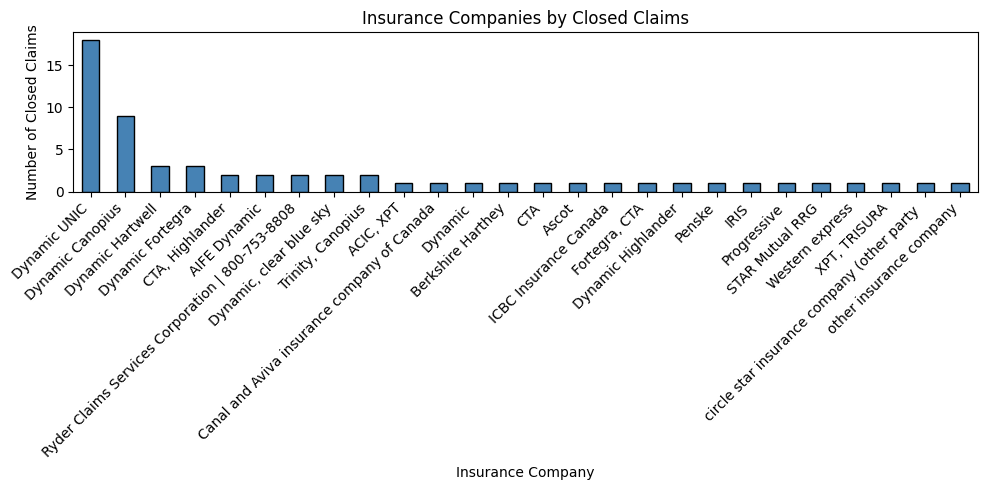

In [886]:
# Bar chart for all Closed claims by insurance companies
closed_counts.head(147).plot(
    kind="bar",
    figsize=(10, 5),
    color="steelblue",
    edgecolor="black"
)
plt.title("Insurance Companies by Closed Claims")
plt.xlabel("Insurance Company")
plt.ylabel("Number of Closed Claims")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

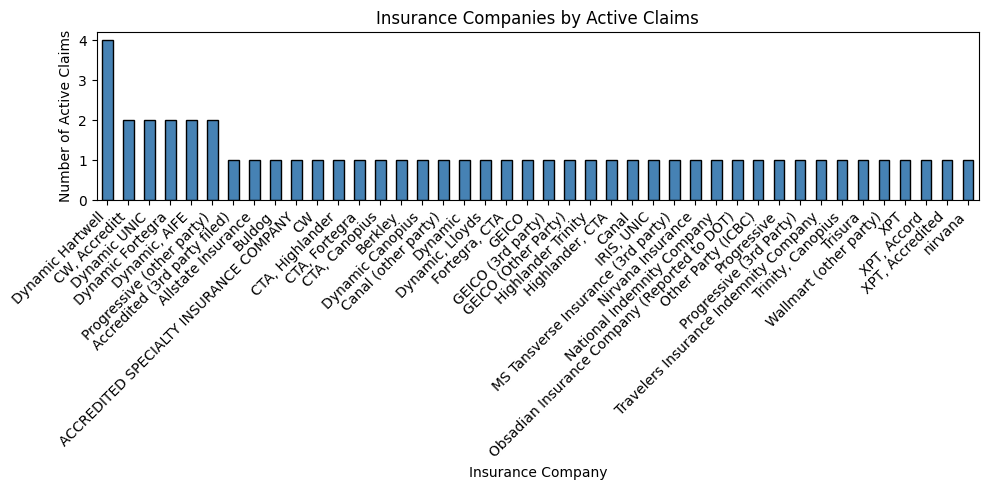

In [887]:
# Bar chart for all Active claims by insurance companies
Active_counts.head(147).plot(
    kind="bar",
    figsize=(10, 5),
    color="steelblue",
    edgecolor="black"
)
plt.title("Insurance Companies by Active Claims")
plt.xlabel("Insurance Company")
plt.ylabel("Number of Active Claims")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

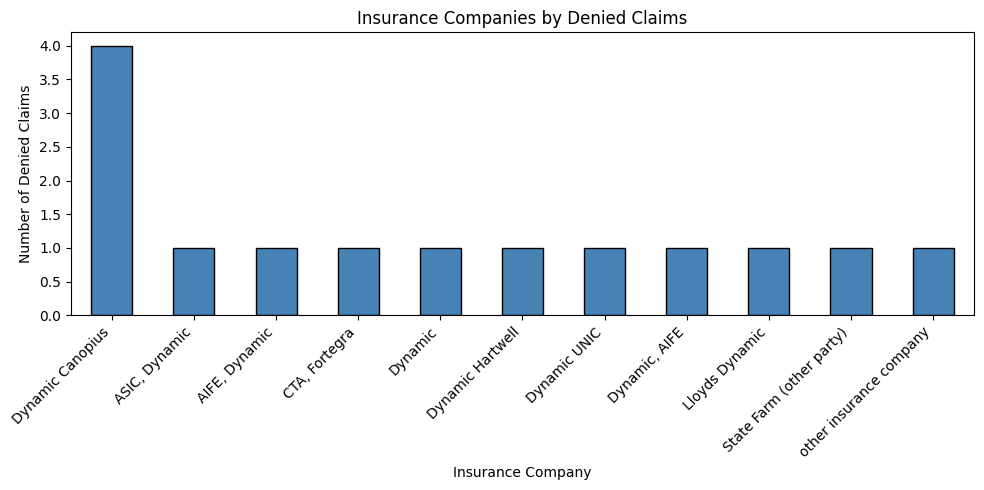

In [888]:
# Bar chart for all declined claims by insurance companies
Denied_counts.head(147).plot(
    kind="bar",
    figsize=(10, 5),
    color="steelblue",
    edgecolor="black"
)
plt.title("Insurance Companies by Denied Claims")
plt.xlabel("Insurance Company")
plt.ylabel("Number of Denied Claims")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

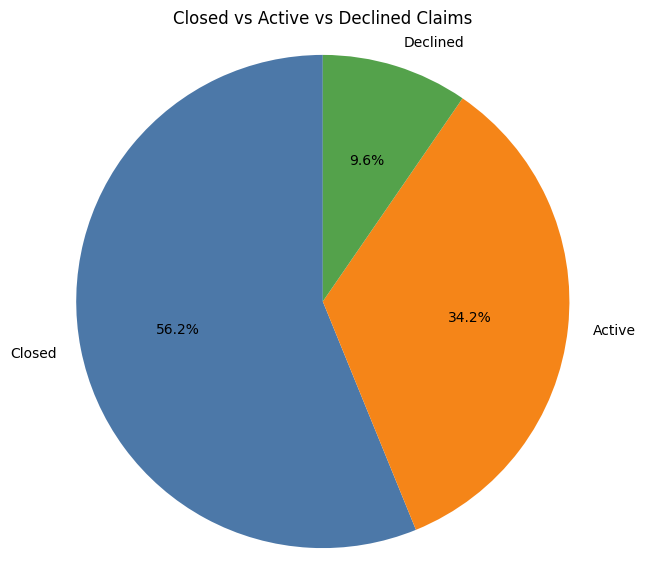

In [889]:
# Pie chart for Closed vs Active vs Declined claims
status_counts = dataset["Claim_Flag"].value_counts().sort_index()
labels = ["Closed", "Active", "Declined"]
values = [status_counts.get(0, 0), status_counts.get(1, 0), status_counts.get(-1, 0)]

plt.figure(figsize=(7, 7))
plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4C78A8", "#F58518", "#54A24B"]
)
plt.title("Closed vs Active vs Declined Claims")
plt.axis("equal")
plt.show()